# 03 PyCaret 모델링 및 최종 모델 구현

이 notebook에서는 수업에서 배운 PyCaret workflow를 중심으로 고혈압 예측 모델을 구현한다.

기본 흐름은 다음과 같다.

`setup()` → `compare_models()` → 상위 모델 선택 → `tune_model()` → `plot_model()` / `evaluate_model()` → SHAP 해석 → 최종 모델 선정

고혈압 기준은 교수님 피드백 이후 ACC/AHA 2017 기준인 `SBP >= 130` 또는 `DBP >= 80`으로 사용한다.


## 1. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve
)
from sklearn.model_selection import learning_curve, validation_curve

RANDOM_STATE = 123
Path('processed_data').mkdir(exist_ok=True)
Path('models').mkdir(exist_ok=True)
Path('figures').mkdir(exist_ok=True)


In [2]:
# Run once if needed
# !pip install pycaret imbalanced-learn lightgbm xgboost catboost shap streamlit


## 2. 정리된 데이터 불러오기

In [3]:
df = pd.read_csv('processed_data/knhanes_young_hypertension_2017_2023.csv')

print(df.shape)
df.head()


(10319, 24)


,age,sex,HE_BMI,HE_wc,HE_glu,HE_HbA1c,HE_TG,HE_chol,sm_presnt,dr_month,...,HE_HPfh2,HE_HPfh3,mh_stress,N_NA,N_K,HE_sbp,HE_dbp,year,covid_period,hypertension
0,39.0,1.0,21.268015,75.7,85.0,5.2,93.0,172.0,1.0,1.0,...,1.0,0.0,1.0,5149.456302,3231.041442,115.0,78.0,2017,before,0
1,35.0,2.0,20.292201,77.6,86.0,5.6,98.0,172.0,0.0,1.0,...,1.0,0.0,0.0,2312.209126,1663.742918,105.0,75.0,2017,before,0
2,28.0,2.0,21.950821,75.9,98.0,5.5,103.0,225.0,0.0,1.0,...,1.0,0.0,0.0,2435.530257,2872.508449,102.0,69.0,2017,before,0
3,37.0,2.0,21.538187,71.7,86.0,5.1,42.0,184.0,1.0,1.0,...,1.0,0.0,0.0,1519.415724,1617.951940,118.0,77.0,2017,before,0
4,33.0,2.0,20.885981,73.0,79.0,5.1,150.0,201.0,0.0,0.0,...,0.0,0.0,0.0,2942.250466,3201.975654,95.0,69.0,2017,before,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10319 entries, 0 to 10318
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           10319 non-null  float64
 1   sex           10319 non-null  float64
 2   HE_BMI        10280 non-null  float64
 3   HE_wc         10192 non-null  float64
 4   HE_glu        10100 non-null  float64
 5   HE_HbA1c      10092 non-null  float64
 6   HE_TG         10101 non-null  float64
 7   HE_chol       10101 non-null  float64
 8   sm_presnt     10267 non-null  float64
 9   dr_month      10268 non-null  float64
 10  pa_aerobic    9896 non-null   float64
 11  incm          10290 non-null  float64
 12  educ          10025 non-null  float64
 13  HE_HPfh1      10057 non-null  float64
 14  HE_HPfh2      10078 non-null  float64
 15  HE_HPfh3      9647 non-null   float64
 16  mh_stress     10268 non-null  float64
 17  N_NA          8804 non-null   float64
 18  N_K           8804 non-nul

## 3. Feature와 target 선택

`HE_sbp`와 `HE_dbp`는 target을 만들 때 사용한 혈압 변수이므로 모델 feature에서는 제외한다. 이를 통해 data leakage를 방지한다.

HDL은 2022년 이후 측정 시기별 변화 가능성이 있어 주분석 모델에서는 제외한다. LDL은 결측률이 30%를 초과하여 주분석 모델에서 제외한다.

`covid_period`는 COVID의 인과효과가 아니라 조사 시기와 측정환경 차이를 반영하는 보조 변수로만 해석한다.



In [5]:
num_cols = [
    'age', 'HE_BMI', 'HE_wc', 'HE_glu', 'HE_HbA1c', 'HE_TG', 'HE_chol',
    'N_NA', 'N_K'  # 식이(영양) 변수: 나트륨/칼륨 섭취량
]

cat_cols = [
    'sex', 'sm_presnt', 'dr_month', 'pa_aerobic',
    'incm', 'educ',
    'HE_HPfh1', 'HE_HPfh2', 'HE_HPfh3', 'mh_stress',
    'covid_period'
]

features = num_cols + cat_cols
target = 'hypertension'

model_df = df[features + [target]].copy()
model_df.head()


,age,HE_BMI,HE_wc,HE_glu,HE_HbA1c,HE_TG,HE_chol,N_NA,N_K,sex,...,dr_month,pa_aerobic,incm,educ,HE_HPfh1,HE_HPfh2,HE_HPfh3,mh_stress,covid_period,hypertension
0,39.0,21.268015,75.7,85.0,5.2,93.0,172.0,5149.456302,3231.041442,1.0,...,1.0,0.0,1.0,7.0,1.0,1.0,0.0,1.0,before,0
1,35.0,20.292201,77.6,86.0,5.6,98.0,172.0,2312.209126,1663.742918,2.0,...,1.0,0.0,1.0,7.0,1.0,1.0,0.0,0.0,before,0
2,28.0,21.950821,75.9,98.0,5.5,103.0,225.0,2435.530257,2872.508449,2.0,...,1.0,1.0,1.0,7.0,0.0,1.0,0.0,0.0,before,0
3,37.0,21.538187,71.7,86.0,5.1,42.0,184.0,1519.415724,1617.951940,2.0,...,1.0,0.0,1.0,6.0,0.0,1.0,0.0,0.0,before,0
4,33.0,20.885981,73.0,79.0,5.1,150.0,201.0,2942.250466,3201.975654,2.0,...,0.0,0.0,2.0,7.0,0.0,0.0,0.0,0.0,before,0


In [6]:
target_summary = pd.DataFrame({
    'count': model_df[target].value_counts().sort_index(),
    'percent': (model_df[target].value_counts(normalize=True).sort_index() * 100).round(1)
})
target_summary


,count,percent
hypertension,,
0,7947,77.0
1,2372,23.0


130/80 기준을 적용한 뒤 hypertension=1 비율이 약 23%로 증가하였다. Assignment 2의 140/90 기준보다 class imbalance가 완화되었지만, 여전히 양성 class가 더 적으므로 AUC, recall, PR curve를 함께 확인한다.


## 4. PyCaret setup

PyCaret `setup()`에서 전처리를 설정한다.

- 결측치 처리와 categorical encoding은 PyCaret pipeline에서 처리한다.
- numeric feature는 robust normalization을 적용한다.
- class imbalance는 `fix_imbalance=True`를 통해 PyCaret의 SMOTE를 적용하고, 최종 Logistic Regression에서는 `class_weight='balanced'`도 함께 사용한다.
- 모델 비교는 5-fold cross-validation으로 수행한다.



In [7]:
from pycaret.classification import *

In [8]:
clf = setup(
    data=model_df,
    target=target,
    categorical_features=cat_cols,
    numeric_features=num_cols,
    session_id=RANDOM_STATE,
    train_size=0.8,
    normalize=True,
    normalize_method='robust',
    fix_imbalance=True,
    fold=5,
    html=False,
    verbose=True
)


                    Description             Value
0                    Session id               123
1                        Target      hypertension
2                   Target type            Binary
3           Original data shape       (10319, 21)
4        Transformed data shape       (14778, 32)
5   Transformed train set shape       (12714, 32)
6    Transformed test set shape        (2064, 32)
7              Numeric features                 9
8          Categorical features                11
9      Rows with missing values             26.6%
10                   Preprocess              True
11              Imputation type            simple
12           Numeric imputation              mean
13       Categorical imputation              mode
14     Maximum one-hot encoding                25
15              Encoding method              None
16                Fix imbalance              True
17         Fix imbalance method             SMOTE
18                    Normalize              True


## 5. 모델 Screening: compare_models()

Logistic Regression, Random Forest, LightGBM, XGBoost, CatBoost를 비교한다. 과제 rubric에서 XGBoost와 CatBoost가 요구되므로 두 모델을 모두 포함하였다.


In [9]:
top3_models = compare_models(
    include=['lr', 'rf', 'lightgbm', 'xgboost', 'catboost'],
    sort='AUC',
    n_select=3
)

top3_models


Processing:   0%|          | 0/27 [00:00<?, ?it/s]

Processing:  19%|█▊        | 5/27 [00:08<00:37,  1.70s/it]

Processing:  26%|██▌       | 7/27 [00:08<00:22,  1.10s/it]

Processing:  33%|███▎      | 9/27 [00:16<00:37,  2.06s/it]

Processing:  41%|████      | 11/27 [00:16<00:22,  1.41s/it]

...

Processing:  85%|████████▌ | 23/27 [00:53<00:11,  2.86s/it]

Processing:  93%|█████████▎| 25/27 [01:39<00:17,  8.89s/it]

Processing: 100%|██████████| 27/27 [01:39<00:00,  6.23s/it]

                                    Model  Accuracy     AUC  Recall   Prec.  \
lr                    Logistic Regression    0.7158  0.7867  0.7208  0.4296   
rf               Random Forest Classifier    0.7958  0.7788  0.3609  0.5919   
catboost              CatBoost Classifier    0.7914  0.7756  0.3498  0.5763   
lightgbm  Light Gradient Boosting Machine    0.7943  0.7727  0.3604  0.5849   
xgboost         Extreme Gradient Boosting    0.7828  0.7499  0.3614  0.5408   

              F1   Kappa     MCC  TT (Sec)  
lr        0.5382  0.3514  0.3762     1.694  
rf        0.4479  0.3317  0.3472     1.564  
catboost  0.4352  0.3166  0.3315     9.126  
lightgbm  0.4456  0.3282  0.3428     1.944  
xgboost   0.4331  0.3054  0.3149     1.594  


[LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                    intercept_scaling=1, l1_ratio=None, max_iter=1000,
                    multi_class='auto', n_jobs=None, penalty='l2',
                    random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                    warm_start=False),
 RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                        criterion='gini', max_depth=None, max_features='sqrt',
                        max_leaf_nodes=None, max_samples=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, n_estimators=100, n_jobs=-1,
                        oob_score=False, random_state=123, verbose=0,
                        warm_start=False),

In [10]:
compare_results = pull()
compare_summary = compare_results[['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'F1']].copy()
compare_summary.to_csv('processed_data/model_comparison_summary.csv', index=False, encoding='utf-8-sig')
compare_summary


,Model,Accuracy,AUC,Recall,Prec.,F1
lr,Logistic Regression,0.7158,0.7867,0.7208,0.4296,0.5382
rf,Random Forest Classifier,0.7958,0.7788,0.3609,0.5919,0.4479
catboost,CatBoost Classifier,0.7914,0.7756,0.3498,0.5763,0.4352
lightgbm,Light Gradient Boosting Machine,0.7943,0.7727,0.3604,0.5849,0.4456
xgboost,Extreme Gradient Boosting,0.7828,0.7499,0.3614,0.5408,0.4331


In [11]:
top3_summary = compare_summary.head(3).copy()
top3_summary.to_csv('processed_data/top3_model_summary.csv', index=False, encoding='utf-8-sig')
top3_summary


,Model,Accuracy,AUC,Recall,Prec.,F1
lr,Logistic Regression,0.7158,0.7867,0.7208,0.4296,0.5382
rf,Random Forest Classifier,0.7958,0.7788,0.3609,0.5919,0.4479
catboost,CatBoost Classifier,0.7914,0.7756,0.3498,0.5763,0.4352


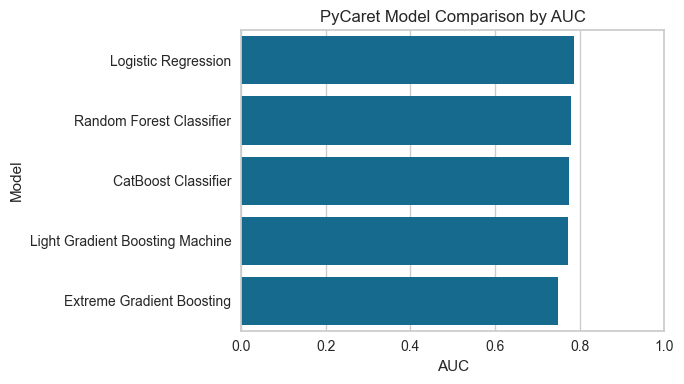

In [12]:
plt.figure(figsize=(7, 4))
sns.barplot(data=compare_summary.reset_index(), x='AUC', y='Model')
plt.title('PyCaret Model Comparison by AUC')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('figures/model_comparison_auc.png', dpi=200)
plt.show()


모델 비교에서는 AUC를 중심으로 보되, hypertension=1을 얼마나 찾는지 recall도 함께 확인한다. Accuracy가 높아도 양성 class를 거의 찾지 못하면 screening 목적에는 적절하지 않을 수 있다.


## 6. 상위 3개 모델 시각화

상위 3개 모델에 대해 Confusion Matrix, ROC Curve, Feature Importance를 확인한다. 모델에 따라 feature importance가 지원되지 않을 수 있다.


Top model 1


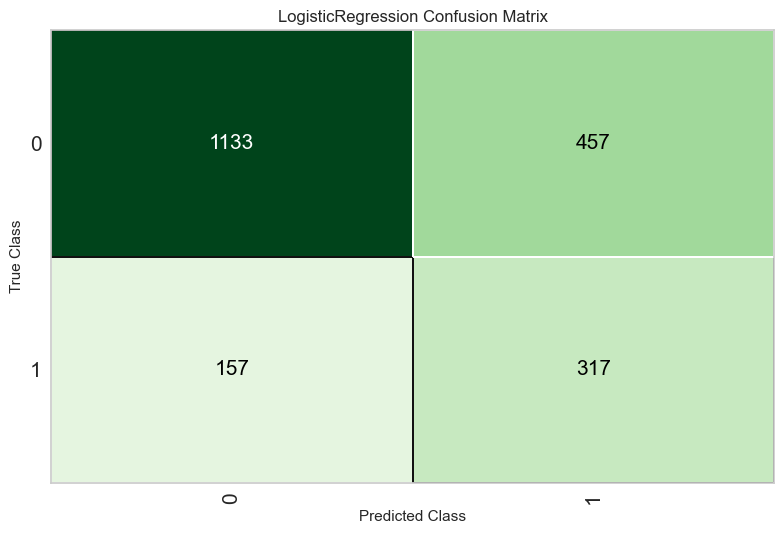

Top model 2


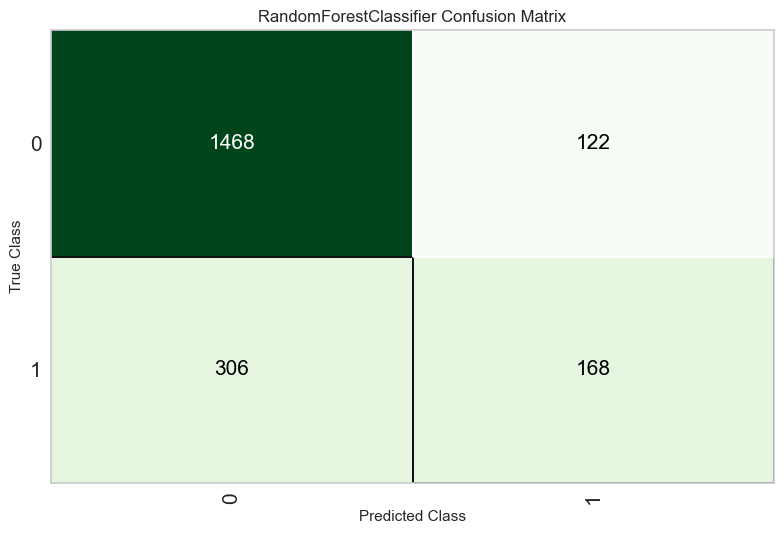

Top model 3


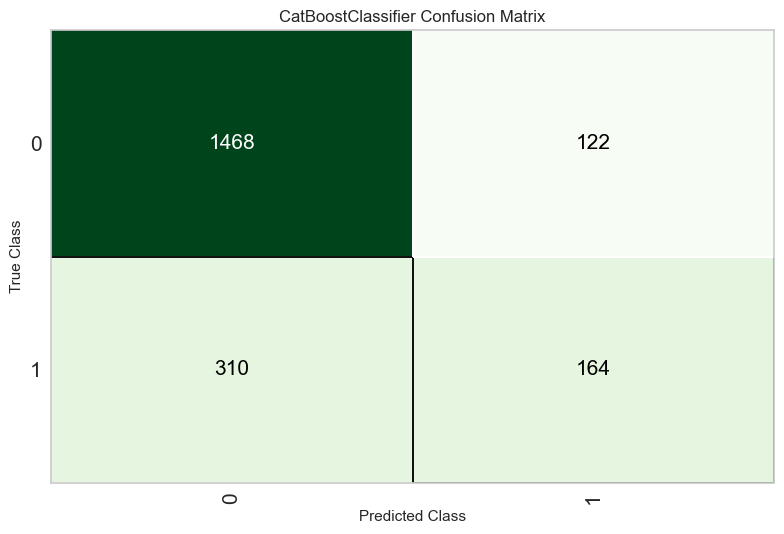

In [13]:
for i, model in enumerate(top3_models, start=1):
    print('Top model', i)
    plot_model(model, plot='confusion_matrix')


Top model 1


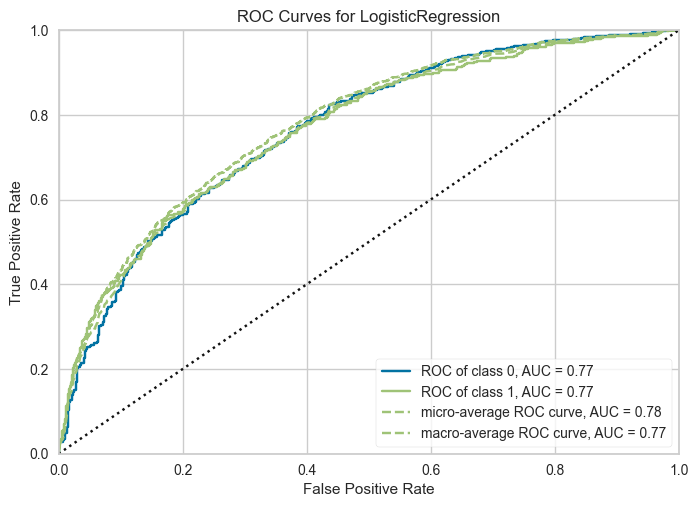

Top model 2


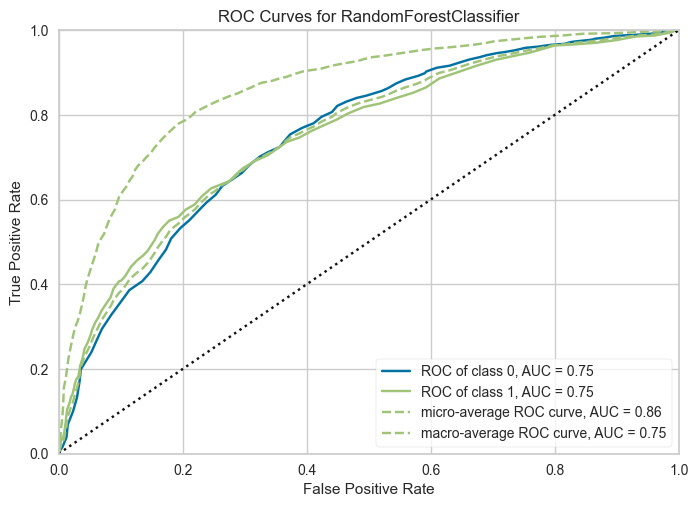

Top model 3


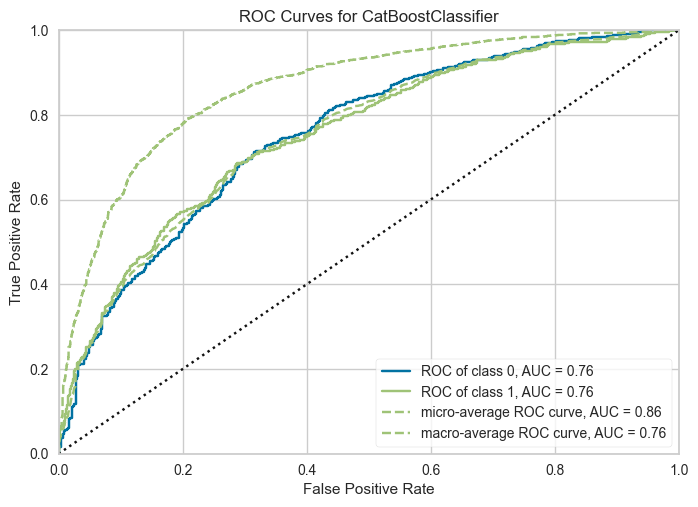

In [14]:
for i, model in enumerate(top3_models, start=1):
    print('Top model', i)
    plot_model(model, plot='auc')


Top model 1


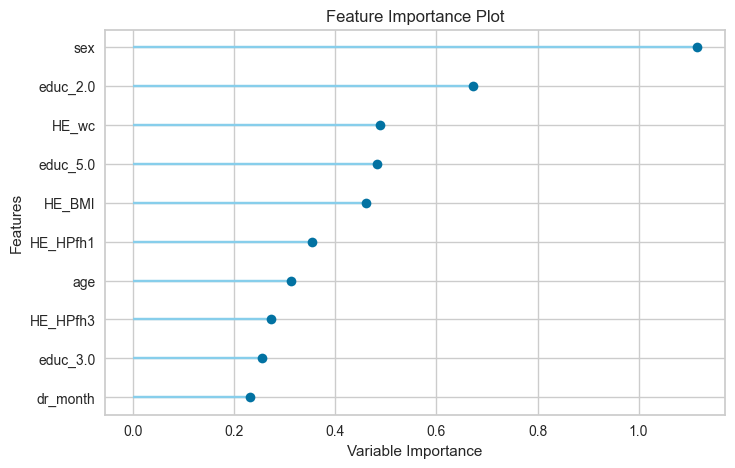

Top model 2


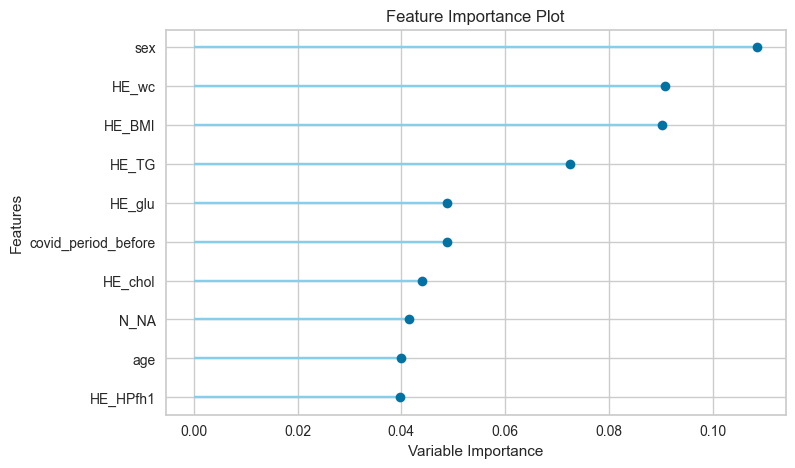

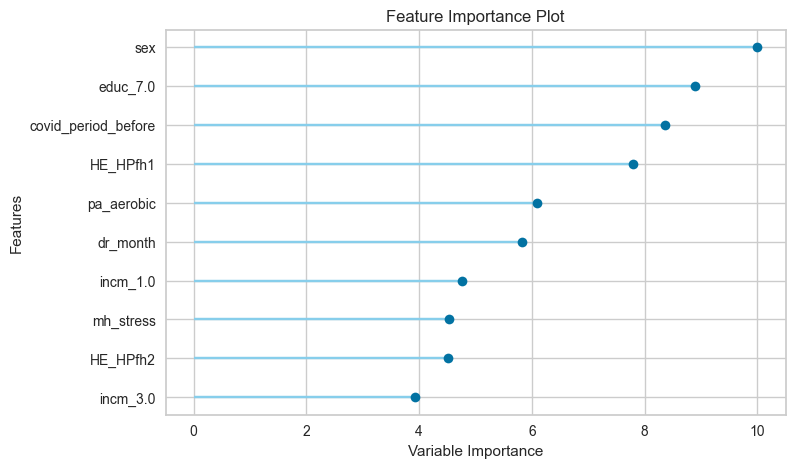

Top model 3


In [15]:
for i, model in enumerate(top3_models, start=1):
    print('Top model', i)
    try:
        plot_model(model, plot='feature')
    except Exception as e:
        print('Feature importance is not available for this model.')
        print(e)


## 7. 최종 모델 선정 및 tune_model()

AUC 기준 가장 높은 모델은 Logistic Regression이었다. 또한 Logistic Regression은 recall이 높고 coefficient 해석이 쉬워 최종 모델로 선정하였다.

최종 모델은 `tune_model()`로 AUC 기준 tuning을 수행하였다.


### 하이퍼파라미터 튜닝 (명시)
`compare_models`로 선정한 최상위 모델(Logistic Regression)에 대해 `tune_model`을 적용한다. 
탐색 기준은 **AUC**, 반복 횟수는 **n_iter=10**, 검증은 **5-fold 교차검증**이다. 
아래 셀에서 튜닝된 모델과 최적 하이퍼파라미터를 출력하여 과정을 명시한다.

In [16]:
best_model = top3_models[0]
tuned_best_model = tune_model(best_model, optimize='AUC', n_iter=10)


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Processing:  43%|████▎     | 3/7 [00:08<00:11,  2.77s/it]

Processing:  86%|████████▌ | 6/7 [00:09<00:01,  1.34s/it]

Processing: 100%|██████████| 7/7 [00:09<00:00,  1.17s/it]

      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7262  0.8011  0.7625  0.4439  0.5612  0.3818  0.4113
1       0.7093  0.7526  0.6755  0.4176  0.5161  0.3245  0.3436
2       0.7244  0.7940  0.7237  0.4400  0.5473  0.3657  0.3891
3       0.7208  0.7932  0.7105  0.4348  0.5395  0.3554  0.3774
4       0.7075  0.7949  0.7342  0.4221  0.5360  0.3444  0.3726
Mean    0.7176  0.7872  0.7213  0.4317  0.5400  0.3543  0.3788
Std     0.0078  0.0175  0.0286  0.0102  0.0147  0.0194  0.0221


In [17]:
# 튜닝 결과 명시: 최종 모델의 하이퍼파라미터
print('Tuned model:', tuned_best_model)
print('\nBest hyperparameters:')
for k, v in tuned_best_model.get_params().items():
    print(f'  {k}: {v}')

Tuned model: LogisticRegression(C=0.049, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

Best hyperparameters:
  C: 0.049
  class_weight: balanced
  dual: False
  fit_intercept: True
  intercept_scaling: 1
  l1_ratio: None
  max_iter: 1000
  multi_class: auto
  n_jobs: None
  penalty: l2
  random_state: 123
  solver: lbfgs
  tol: 0.0001
  verbose: 0
  warm_start: False


In [18]:
tune_results = pull()
tune_results.to_csv('processed_data/final_pipeline_cv_results.csv', index=False, encoding='utf-8-sig')
tune_results


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7262,0.8011,0.7625,0.4439,0.5612,0.3818,0.4113
1,0.7093,0.7526,0.6755,0.4176,0.5161,0.3245,0.3436
2,0.7244,0.7940,0.7237,0.4400,0.5473,0.3657,0.3891
3,0.7208,0.7932,0.7105,0.4348,0.5395,0.3554,0.3774
4,0.7075,0.7949,0.7342,0.4221,0.5360,0.3444,0.3726
Mean,0.7176,0.7872,0.7213,0.4317,0.5400,0.3543,0.3788
Std,0.0078,0.0175,0.0286,0.0102,0.0147,0.0194,0.0221


## 8. evaluate_model()

PyCaret의 `evaluate_model()`은 notebook에서 interactive하게 여러 plot을 확인할 수 있는 함수이다. 자동 실행 환경에서는 화면이 복잡할 수 있어, 아래 cell은 발표 준비나 수동 확인 시 실행한다.


In [19]:
# Interactive dashboard for manual review in Jupyter/Colab
# evaluate_model(tuned_best_model)


## 9. 최종 모델 Holdout 평가

In [20]:
pred_holdout = predict_model(tuned_best_model, raw_score=True)
pred_holdout.head()


                 Model  Accuracy     AUC  Recall   Prec.      F1   Kappa  \
0  Logistic Regression    0.7025  0.7665  0.6667  0.4093  0.5072  0.3112   

      MCC  
0  0.3302  


,age,HE_BMI,HE_wc,HE_glu,HE_HbA1c,HE_TG,HE_chol,N_NA,N_K,sex,...,educ,HE_HPfh1,HE_HPfh2,HE_HPfh3,mh_stress,covid_period,hypertension,prediction_label,prediction_score_0,prediction_score_1
3491,27.0,25.324345,76.000000,88.0,5.1,73.0,180.0,1804.595093,2230.398682,2.0,...,8.0,0.0,0.0,0.0,0.0,before,0,0,0.7260,0.2740
112,37.0,28.413929,90.800003,101.0,5.2,55.0,251.0,4114.095215,1406.221802,2.0,...,5.0,0.0,0.0,0.0,0.0,before,0,1,0.3197,0.6803
4859,30.0,15.731629,60.099998,95.0,5.2,44.0,165.0,2592.864502,1808.599609,2.0,...,7.0,0.0,0.0,0.0,0.0,before,0,0,0.8832,0.1168
7936,32.0,21.000912,69.300003,87.0,4.7,123.0,226.0,1232.697266,1582.745117,2.0,...,4.0,0.0,0.0,0.0,0.0,after,0,0,0.9036,0.0964
1660,38.0,14.661224,61.799999,91.0,5.4,60.0,190.0,2255.613281,2195.270752,2.0,...,7.0,1.0,0.0,0.0,0.0,before,0,0,0.8219,0.1781


In [21]:
y_true = pred_holdout[target]
y_pred = pred_holdout['prediction_label']

if 'prediction_score_1' in pred_holdout.columns:
    y_score = pred_holdout['prediction_score_1']
else:
    y_score = pred_holdout['prediction_score']

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
cm_df


,Predicted 0,Predicted 1
Actual 0,1134,456
Actual 1,158,316


In [22]:
tn, fp, fn, tp = cm.ravel()
report_dict = classification_report(y_true, y_pred, output_dict=True)

metric_summary = pd.DataFrame({
    'Metric': ['TN', 'FP', 'FN', 'TP', 'Precision', 'Recall', 'F1', 'ROC AUC', 'Average Precision'],
    'Value': [
        tn, fp, fn, tp,
        round(report_dict['1']['precision'], 3),
        round(report_dict['1']['recall'], 3),
        round(report_dict['1']['f1-score'], 3),
        round(roc_auc_score(y_true, y_score), 3),
        round(average_precision_score(y_true, y_score), 3)
    ]
})

metric_summary.to_csv('processed_data/final_model_metric_summary.csv', index=False, encoding='utf-8-sig')
cm_df.to_csv('processed_data/final_model_confusion_matrix.csv', encoding='utf-8-sig')
metric_summary


,Metric,Value
0,TN,1134.000
1,FP,456.000
2,FN,158.000
3,TP,316.000
4,Precision,0.409
5,Recall,0.667
6,F1,0.507
7,ROC AUC,0.766
8,Average Precision,0.516


In [23]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.71      0.79      1590
           1       0.41      0.67      0.51       474

    accuracy                           0.70      2064
   macro avg       0.64      0.69      0.65      2064
weighted avg       0.77      0.70      0.72      2064



## 10. 최종 모델 plot_model()

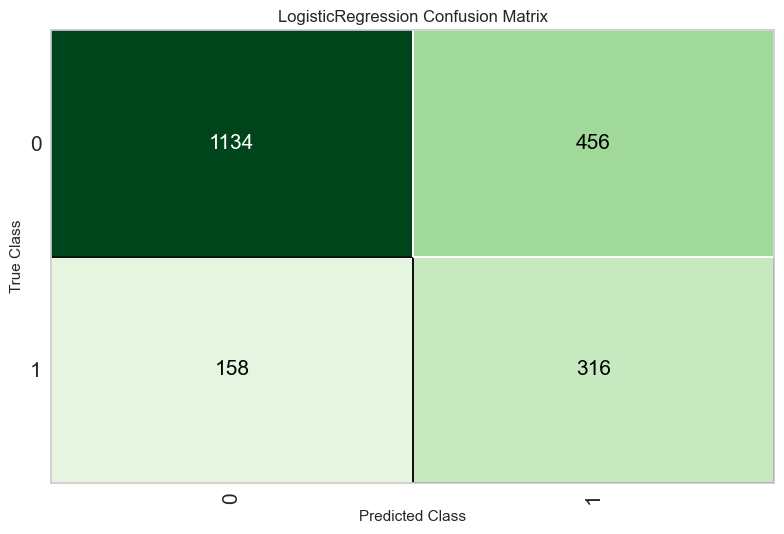

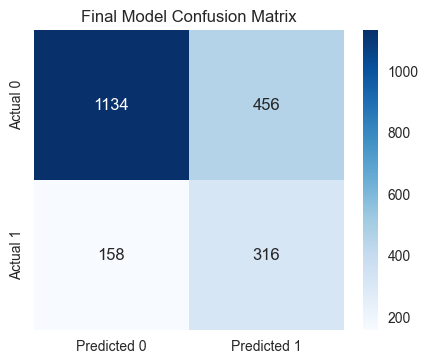

In [24]:
plot_model(tuned_best_model, plot='confusion_matrix')

plt.figure(figsize=(4.5, 3.8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Final Model Confusion Matrix')
plt.tight_layout()
plt.savefig('figures/final_confusion_matrix.png', dpi=200)
plt.show()


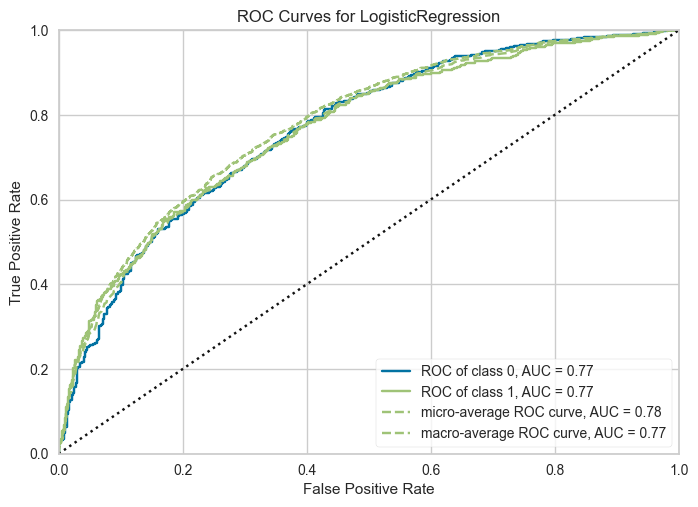

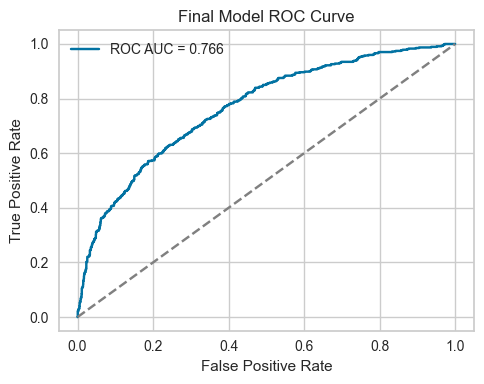

In [25]:
plot_model(tuned_best_model, plot='auc')

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final Model ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('figures/final_roc_curve.png', dpi=200)
plt.show()


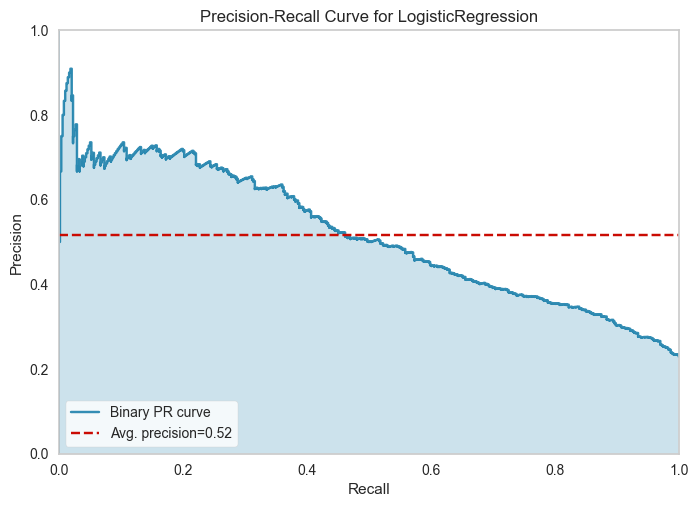

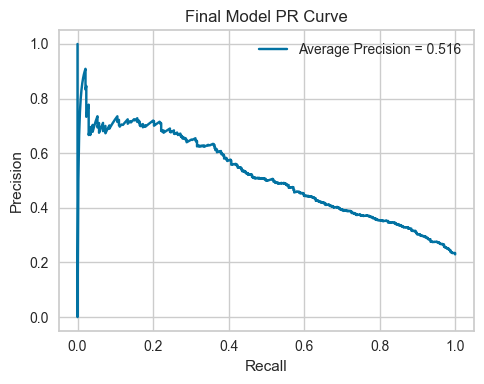

In [26]:
plot_model(tuned_best_model, plot='pr')

precision, recall, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

plt.figure(figsize=(5, 4))
plt.plot(recall, precision, label=f'Average Precision = {ap:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Final Model PR Curve')
plt.legend()
plt.tight_layout()
plt.savefig('figures/final_pr_curve.png', dpi=200)
plt.show()


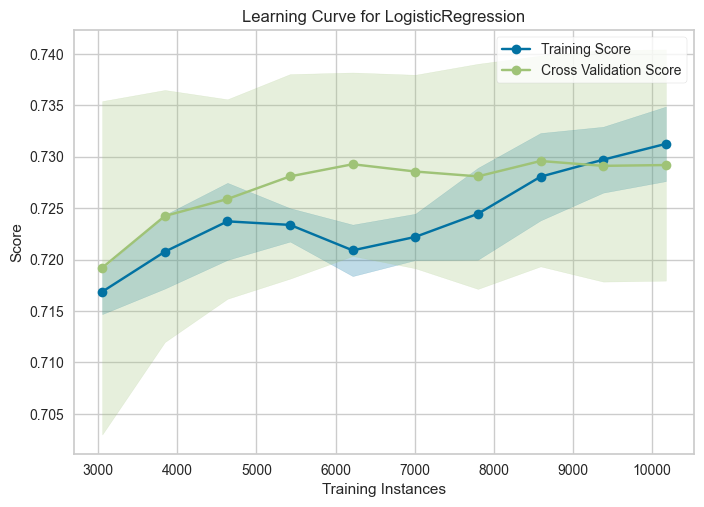

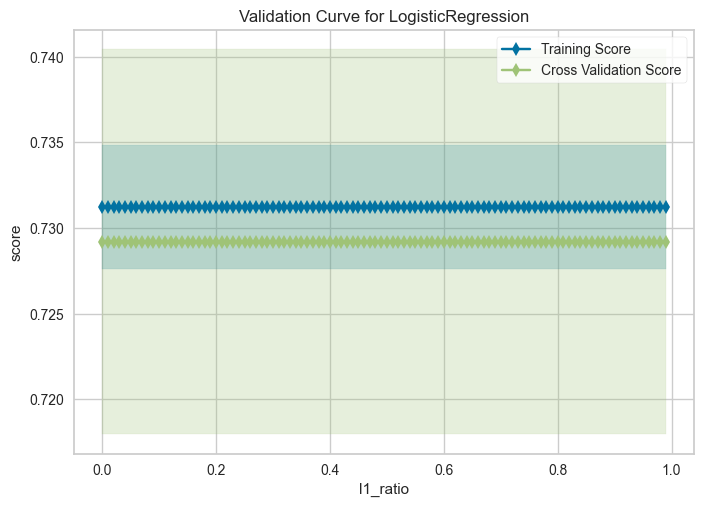

In [27]:
plot_model(tuned_best_model, plot='learning')
plot_model(tuned_best_model, plot='vc')

# Save simple copies for the report from PyCaret-generated plot display is difficult,
# so the report uses the visible notebook plots and final metric tables.


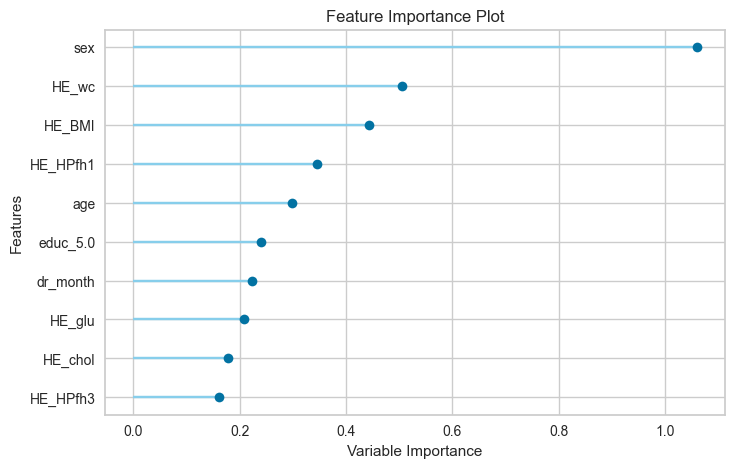

In [28]:
try:
    plot_model(tuned_best_model, plot='feature')
except Exception as e:
    print('Feature importance is not available for this model.')
    print(e)


Confusion Matrix, ROC Curve, PR Curve, Learning Curve, Validation Curve를 확인하였다. PR Curve는 양성 class가 상대적으로 적은 상황에서 precision과 recall의 관계를 보기 위해 추가로 확인한다.


## 11. Feature Importance 정리

In [29]:
# PyCaret final model object is based on a scikit-learn pipeline.
# Coefficient-based importance is used for the tuned Logistic Regression.
try:
    feature_names = get_config('X_train_transformed').columns
    coef = tuned_best_model.coef_[0]
except Exception:
    feature_names = [f'feature_{i}' for i in range(len(tuned_best_model.coef_[0]))]
    coef = tuned_best_model.coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef,
    'abs_coefficient': np.abs(coef)
}).sort_values('abs_coefficient', ascending=False)

coef_df.to_csv('processed_data/final_model_feature_importance.csv', index=False, encoding='utf-8-sig')
coef_df.head(15)


,feature,coefficient,abs_coefficient
9,sex,-1.060423,1.060423
2,HE_wc,0.504812,0.504812
1,HE_BMI,0.443942,0.443942
24,HE_HPfh1,0.345707,0.345707
0,age,0.298126,0.298126
19,educ_5.0,0.240743,0.240743
11,dr_month,0.223869,0.223869
3,HE_glu,0.207879,0.207879
6,HE_chol,0.178935,0.178935
26,HE_HPfh3,0.161451,0.161451


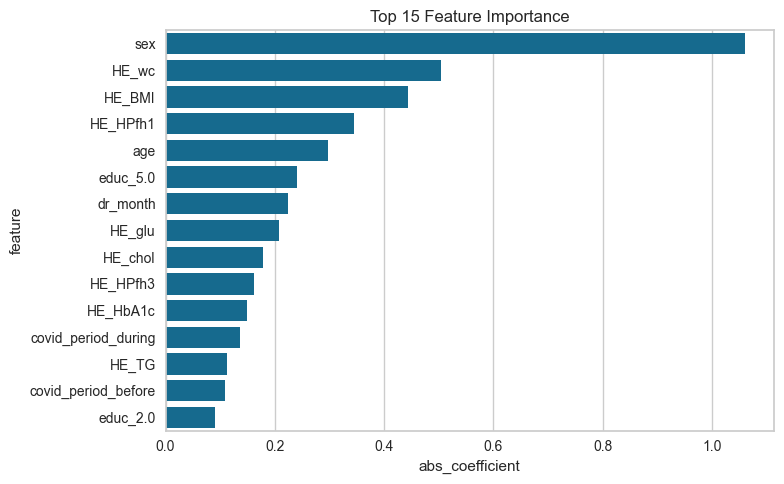

In [30]:
top_coef = coef_df.head(15).copy()

plt.figure(figsize=(8, 5))
sns.barplot(data=top_coef, x='abs_coefficient', y='feature')
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.savefig('figures/final_feature_importance.png', dpi=200)
plt.show()


Feature importance는 인과관계가 아니라 예측 과정에서 어떤 변수가 상대적으로 많이 사용되었는지를 보여주는 참고 자료로 해석한다.


## 12. SHAP 해석

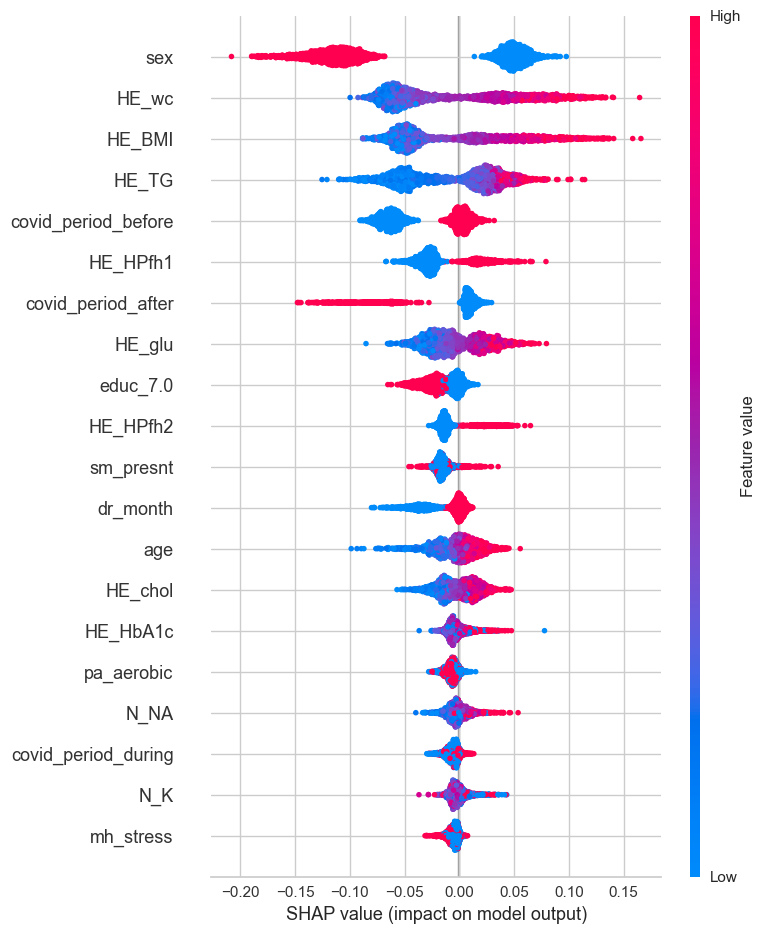

In [31]:
# PyCaret interpret_model supports SHAP mainly for tree-based models.
# Logistic Regression is the final model, so SHAP is checked using the best tree-based model among top candidates.
tree_model_for_shap = None
for model in top3_models:
    model_name = model.__class__.__name__.lower()
    if any(key in model_name for key in ['catboost', 'xgb', 'lgbm', 'forest']):
        tree_model_for_shap = model
        break

if tree_model_for_shap is not None:
    try:
        interpret_model(tree_model_for_shap, plot='summary')
    except Exception as e:
        print('PyCaret SHAP interpretation was not available in this environment.')
        print(e)
else:
    print('No tree-based model found for PyCaret SHAP interpretation.')


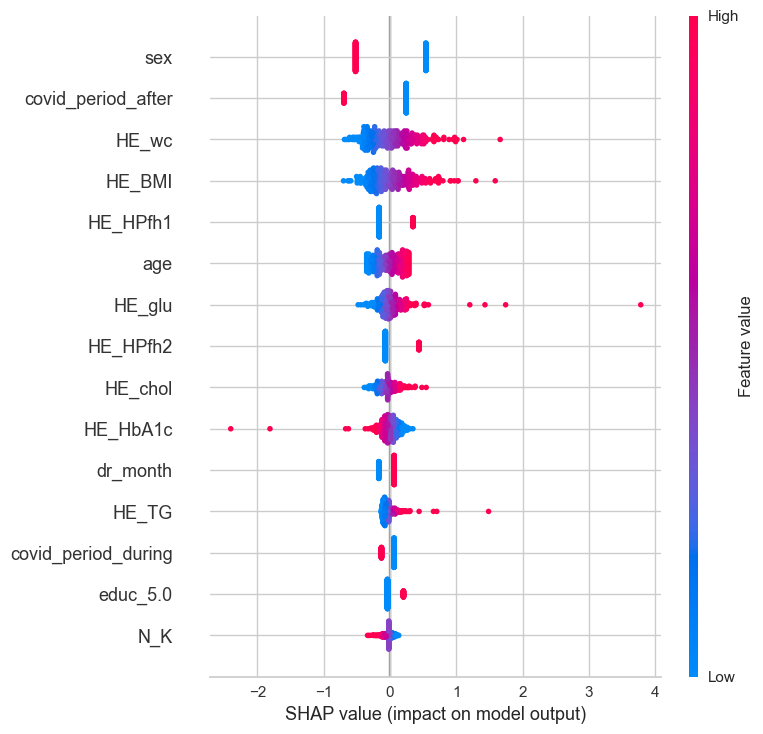

,feature,mean_abs_shap
9,sex,0.529858
29,covid_period_after,0.357038
2,HE_wc,0.292495
1,HE_BMI,0.259110
24,HE_HPfh1,0.206224
0,age,0.172325
3,HE_glu,0.152719
25,HE_HPfh2,0.146471
6,HE_chol,0.118404
4,HE_HbA1c,0.111180


In [32]:
# Supplementary SHAP for the final Logistic Regression model.
# This is used because PyCaret interpret_model does not directly support LR SHAP.
import shap

X_train_transformed = get_config('X_train_transformed')
X_test_transformed = get_config('X_test_transformed')

sample_size = min(300, X_test_transformed.shape[0])
background_size = min(300, X_train_transformed.shape[0])

explainer = shap.LinearExplainer(
    tuned_best_model,
    X_train_transformed.iloc[:background_size]
)
shap_values = explainer(X_test_transformed.iloc[:sample_size])

plt.figure()
shap.summary_plot(
    shap_values.values,
    X_test_transformed.iloc[:sample_size],
    feature_names=X_test_transformed.columns,
    show=False,
    max_display=15
)
plt.tight_layout()
plt.savefig('figures/shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()

shap_importance = pd.DataFrame({
    'feature': X_test_transformed.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

shap_importance.to_csv('processed_data/shap_feature_importance.csv', index=False, encoding='utf-8-sig')
shap_importance.head(15)


SHAP도 feature importance와 마찬가지로 인과관계로 해석하지 않는다. 모델이 예측할 때 어떤 변수값을 상대적으로 많이 참고했는지 설명하기 위한 도구로 사용한다.


## 13. 최종 모델 저장

In [33]:
save_model(tuned_best_model, 'models/final_hypertension_model')

print('Saved model: models/final_hypertension_model.pkl')


Transformation Pipeline and Model Successfully Saved


Saved model: models/final_hypertension_model.pkl


## 14. 간단 정리

이 notebook에서는 PyCaret workflow를 중심으로 모델링을 수행하였다.

`setup()`에서 전처리와 class imbalance 처리를 설정하고, `compare_models()`로 Logistic Regression, Random Forest, LightGBM, XGBoost, CatBoost를 비교하였다. Class imbalance는 SMOTE와 최종 Logistic Regression의 `class_weight='balanced'`를 함께 사용하여 처리하였다. 이후 `tune_model()`로 최종 Logistic Regression 모델을 tuning하고, `plot_model()`과 SHAP을 사용해 모델을 해석하였다.

COVID period는 인과효과가 아니라 조사 시기 및 측정환경 차이를 함께 반영하는 변수로 제한해서 해석한다.



## Table 1. 연구참여자 분포 통계 비교

보고서 Result 3.1의 참여자 분포 표를 산출한다. 고혈압 여부에 따라 수치형 변수는 독립표본 t-검정(Welch's t-test), 범주형 변수(성별)는 카이제곱 검정으로 비교한다. 교수님 피드백으로 추가한 식이 변수인 나트륨 섭취량(N_NA)과 칼륨 섭취량(N_K)도 함께 확인한다.


In [34]:
# Table 1: 연구참여자 분포 통계 비교 (p-value 산출)
from scipy import stats

g0 = df[df['hypertension'] == 0]
g1 = df[df['hypertension'] == 1]

numeric_vars = [
    ('age', '나이'),
    ('HE_BMI', 'BMI'),
    ('HE_wc', '허리둘레'),
    ('HE_glu', '공복혈당'),
    ('HE_HbA1c', 'HbA1c'),
    ('HE_TG', '중성지방'),
    ('HE_chol', '총콜레스테롤'),
    ('N_NA', '나트륨 섭취량'),
    ('N_K', '칼륨 섭취량'),
]

rows = []
for c, label in numeric_vars:
    a, b = g0[c].dropna(), g1[c].dropna()
    pval = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit').pvalue
    rows.append({
        'variable': c,
        'label': label,
        f'Normal (n={len(g0)})': f'{a.mean():.1f} \u00b1 {a.std():.1f}',
        f'Hypertension (n={len(g1)})': f'{b.mean():.1f} \u00b1 {b.std():.1f}',
        'test': "Welch's t-test",
        'p': '<0.001' if pval < 0.001 else f'{pval:.3f}',
    })

# 성별(범주형) -> chi-square
ct = pd.crosstab(df['hypertension'], df['sex'])
p_sex = stats.chi2_contingency(ct)[1]
rows.append({
    'variable': 'sex_male',
    'label': '남성 비율(%)',
    f'Normal (n={len(g0)})': f"{(g0['sex'] == 1).mean() * 100:.1f}",
    f'Hypertension (n={len(g1)})': f"{(g1['sex'] == 1).mean() * 100:.1f}",
    'test': 'Chi-square test',
    'p': '<0.001' if p_sex < 0.001 else f'{p_sex:.3f}',
})

table1 = pd.DataFrame(rows)
table1.to_csv('processed_data/table1_statistical_comparison.csv', index=False, encoding='utf-8-sig')
table1


variable,label,Normal (n=7947),Hypertension (n=2372),test,p
age,나이,29.5 ± 6.1,31.2 ± 5.9,Welch's t-test,<0.001
HE_BMI,BMI,22.9 ± 3.8,26.3 ± 5.0,Welch's t-test,<0.001
HE_wc,허리둘레,77.9 ± 10.7,88.3 ± 12.8,Welch's t-test,<0.001
HE_glu,공복혈당,91.1 ± 12.4,97.8 ± 20.2,Welch's t-test,<0.001
HE_HbA1c,HbA1c,5.3 ± 0.4,5.5 ± 0.7,Welch's t-test,<0.001
HE_TG,중성지방,101.9 ± 75.5,158.0 ± 134.5,Welch's t-test,<0.001
HE_chol,총콜레스테롤,185.7 ± 33.3,198.2 ± 34.8,Welch's t-test,<0.001
N_NA,나트륨 섭취량,3214.0 ± 1872.0,3807.4 ± 2268.2,Welch's t-test,<0.001
N_K,칼륨 섭취량,2489.0 ± 1213.3,2724.0 ± 1338.4,Welch's t-test,<0.001
sex_male,남성 비율(%),39.0,71.1,Chi-square test,<0.001
